# ResNet50 com transfer learning

Fine-tuning completo de uma ResNet50 pré-treinada na ImageNet para as 38 classes do PlantVillage. O treinamento, a seleção do checkpoint e todas as métricas desta etapa usam somente `train` e `validation`. **O conjunto de teste permanece reservado e não é iterado neste notebook.**

## Caminhos e ambiente

A configuração abaixo funciona localmente e no Google Colab. No Colab, o Drive é montado e o repositório é localizado ou clonado automaticamente em `MyDrive/plant-disease-classification`, preservando dados e resultados entre sessões.

In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REPOSITORY_URL = 'https://github.com/murilodc/plant-disease-classification.git'
COLAB_PROJECT_DIR = Path('/content/plant-disease-classification')
LEGACY_COLAB_PROJECT_DIR = Path('/content/tcc-plant-disease-classification')
DRIVE_PROJECT_DIR = Path('/content/drive/MyDrive/plant-disease-classification')
LEGACY_DRIVE_PROJECT_DIR = Path('/content/drive/MyDrive/TCC')
AUTO_CLONE_REPOSITORY = True
MOUNT_DRIVE = True
if IN_COLAB and MOUNT_DRIVE:
    drive.mount('/content/drive')


def is_project_root(path: Path) -> bool:
    return (path / 'src' / 'train_resnet50.py').is_file()


def find_project_root() -> Path:
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    if IN_COLAB:
        candidates.extend([
            DRIVE_PROJECT_DIR, LEGACY_DRIVE_PROJECT_DIR,
            COLAB_PROJECT_DIR, LEGACY_COLAB_PROJECT_DIR,
        ])
    for candidate in candidates:
        if is_project_root(candidate):
            return candidate

    if IN_COLAB and AUTO_CLONE_REPOSITORY:
        clone_target = DRIVE_PROJECT_DIR if MOUNT_DRIVE else COLAB_PROJECT_DIR
        if clone_target.exists():
            raise FileNotFoundError(
                f'{clone_target} já existe, mas não contém o projeto completo. '
                'Remova ou renomeie esse diretório e execute a célula novamente.'
            )
        print('Clonando o repositório para o Colab...')
        subprocess.check_call([
            'git', 'clone', '--depth', '1', REPOSITORY_URL, str(clone_target)
        ])
        if is_project_root(clone_target):
            return clone_target

    raise FileNotFoundError(
        'Projeto não encontrado. Envie o repositório completo, monte o Drive '
        'ou habilite AUTO_CLONE_REPOSITORY.'
    )

BASE_DIR = find_project_root()
DATA_DIR = BASE_DIR / 'data'
RESULTS_DIR = BASE_DIR / 'results'
RESNET50_RESULTS_DIR = RESULTS_DIR / 'resnet50'
SRC_DIR = BASE_DIR / 'src'
ZIP_PATH = DATA_DIR / 'data.zip'
LEAF_MAP_PATH = DATA_DIR / 'leaf_grouping' / 'leaf-map.json'
RAW_METADATA_CSV = RESULTS_DIR / 'plantvillage_metadata_raw_color.csv'
METADATA_CSV = RESULTS_DIR / 'plantvillage_metadata_split.csv'
IMAGE_ROOT = Path('/content/plantvillage_color') if IN_COLAB else DATA_DIR / 'plantvillage_color'

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RESNET50_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
if not SRC_DIR.exists():
    raise FileNotFoundError(f'Diretório src não encontrado: {SRC_DIR}')
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print('Base:', BASE_DIR)
print('Resultados da ResNet50:', RESNET50_RESULTS_DIR)
print('Imagens:', IMAGE_ROOT)

Mounted at /content/drive
Base: /content/drive/MyDrive/plant-disease-classification
Resultados da ResNet50: /content/drive/MyDrive/plant-disease-classification/results/resnet50
Imagens: /content/plantvillage_color


## Dependências

In [2]:
required_packages = {
    'torch': 'torch',
    'torchvision': 'torchvision',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'sklearn': 'scikit-learn',
}
missing_packages = [
    package for module_name, package in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]
if missing_packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing_packages])

import json
import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import Image, display

## Protocolo experimental

In [3]:
SEED = 42
NUM_CLASSES = 38
BATCH_SIZE = 32
MAX_EPOCHS = 30
LEARNING_RATE = 1e-4
EARLY_STOPPING_PATIENCE = 5
MIN_DELTA = 1e-4
NUM_WORKERS = 2 if IN_COLAB else 0
REQUIRE_CUDA_IN_COLAB = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if IN_COLAB and REQUIRE_CUDA_IN_COLAB and device.type != 'cuda':
    raise RuntimeError(
        'GPU não disponível. No Colab, selecione Ambiente de execução > '
        'Alterar tipo de ambiente de execução > T4 GPU e execute novamente.'
    )
print('Dispositivo selecionado automaticamente:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

Dispositivo selecionado automaticamente: cuda
GPU: Tesla T4


In [4]:
from plantvillage_audit import build_metadata_dataframe, save_metadata_csv
from plantvillage_pytorch import extract_raw_color_from_zip
from plantvillage_split import save_split_metadata_csv, split_metadata_by_leaf_id
from resnet50_model import (
    DEFAULT_WEIGHTS,
    build_resnet50_transforms,
    create_resnet50,
    resnet50_weights_name,
)
from train_resnet50 import train_resnet50

## Dados e splits existentes

A célula reaproveita as rotinas já usadas pela baseline. O CSV de split existente nunca é refeito; a geração só ocorre quando ele ainda não existe.

In [5]:
DOWNLOAD_DATA_IF_MISSING = True
EXTRACT_IMAGES_IF_MISSING = True

if DOWNLOAD_DATA_IF_MISSING and (not ZIP_PATH.exists() or not LEAF_MAP_PATH.exists()):
    if importlib.util.find_spec('huggingface_hub') is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'huggingface_hub'])
    from huggingface_hub import hf_hub_download
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    if not ZIP_PATH.exists():
        ZIP_PATH = Path(hf_hub_download(
            repo_id='mohanty/PlantVillage', filename='data.zip',
            repo_type='dataset', local_dir=str(DATA_DIR),
        ))
    if not LEAF_MAP_PATH.exists():
        LEAF_MAP_PATH = Path(hf_hub_download(
            repo_id='mohanty/PlantVillage', filename='leaf_grouping/leaf-map.json',
            repo_type='dataset', local_dir=str(DATA_DIR),
        ))

if not METADATA_CSV.exists():
    if not ZIP_PATH.exists() or not LEAF_MAP_PATH.exists():
        raise FileNotFoundError('Arquivos necessários para gerar os splits não encontrados.')
    metadata = build_metadata_dataframe(ZIP_PATH, LEAF_MAP_PATH)
    save_metadata_csv(metadata, RAW_METADATA_CSV)
    metadata_split = split_metadata_by_leaf_id(metadata)
    save_split_metadata_csv(metadata_split, METADATA_CSV)
else:
    print('CSV de split existente reutilizado:', METADATA_CSV)

if EXTRACT_IMAGES_IF_MISSING:
    if not ZIP_PATH.exists():
        raise FileNotFoundError(f'ZIP do PlantVillage não encontrado: {ZIP_PATH}')
    extraction = extract_raw_color_from_zip(ZIP_PATH, IMAGE_ROOT)
    print('Extração:', extraction)
    if int(extraction['total']) != 54_305:
        raise RuntimeError('Extração incompleta: esperadas 54.305 imagens raw/color.')
elif not IMAGE_ROOT.is_dir() or not any(IMAGE_ROOT.iterdir()):
    raise FileNotFoundError(f'Diretório de imagens vazio ou ausente: {IMAGE_ROOT}')

CSV de split existente reutilizado: /content/drive/MyDrive/plant-disease-classification/results/plantvillage_metadata_split.csv
Extração: {'output_dir': '/content/plantvillage_color', 'extracted': 54305, 'skipped': 0, 'total': 54305}


## Conferência do protocolo e preprocessing

A contagem abaixo consulta somente o CSV. Nenhuma imagem do split de teste é carregada. A normalização é obtida diretamente do preset dos pesos ImageNet.

In [6]:
metadata_df = pd.read_csv(METADATA_CSV)
required_columns = {'zip_path', 'classe', 'leaf_id', 'split'}
missing_columns = sorted(required_columns - set(metadata_df.columns))
if missing_columns:
    raise KeyError(f'Colunas ausentes no CSV de split: {missing_columns}')
expected_split_sizes = {'train': 38_008, 'validation': 8_172, 'test': 8_125}
actual_split_sizes = metadata_df['split'].value_counts().to_dict()
if actual_split_sizes != expected_split_sizes:
    raise ValueError(f'Tamanhos de split inesperados: {actual_split_sizes}')
if metadata_df['classe'].nunique() != 38:
    raise ValueError('O CSV de split deve conter exatamente 38 classes.')
if metadata_df.groupby('leaf_id')['split'].nunique().max() != 1:
    raise ValueError('Data leakage: há leaf_id presente em mais de um split.')
split_sizes = metadata_df['split'].value_counts().rename_axis('split').reset_index(name='num_images')
display(split_sizes)

weights_transform = DEFAULT_WEIGHTS.transforms()
print('Pesos:', resnet50_weights_name(DEFAULT_WEIGHTS))
print('Tamanho da entrada:', (224, 224))
print('Média ImageNet:', tuple(weights_transform.mean))
print('Desvio padrão ImageNet:', tuple(weights_transform.std))
print('Transform de treino:', build_resnet50_transforms('train'))
print('Transform de validação:', build_resnet50_transforms('validation'))
print('Split usado para avaliação nesta etapa: validation')
print('Split reservado: test (DataLoader não iterado)')

,split,num_images
0,train,38008
1,validation,8172
2,test,8125


Pesos: ResNet50_Weights.IMAGENET1K_V2
Tamanho da entrada: (224, 224)
Média ImageNet: (0.485, 0.456, 0.406)
Desvio padrão ImageNet: (0.229, 0.224, 0.225)
Transform de treino: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)
Transform de validação: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)
Split usado para avaliação nesta etapa: validation
Split reservado: test (DataLoader não iterado)


## Verificação do modelo pré-treinado

Somente a camada `fc` é substituída. Todos os parâmetros ficam treináveis para fine-tuning completo.

In [7]:
preview_model = create_resnet50(num_classes=NUM_CLASSES)
total_parameters = sum(parameter.numel() for parameter in preview_model.parameters())
trainable_parameters = sum(
    parameter.numel() for parameter in preview_model.parameters() if parameter.requires_grad
)
print('Classe:', type(preview_model).__name__)
print('Camada final:', preview_model.fc)
print('Parâmetros totais:', f'{total_parameters:,}')
print('Parâmetros treináveis:', f'{trainable_parameters:,}')
assert preview_model.fc.out_features == NUM_CLASSES
assert total_parameters == trainable_parameters
del preview_model

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 173MB/s]


Classe: ResNet
Camada final: Linear(in_features=2048, out_features=38, bias=True)
Parâmetros totais: 23,585,894
Parâmetros treináveis: 23,585,894


## Treinamento e avaliação na validação

Esta célula executa o experimento completo quando rodada manualmente: Adam, `CrossEntropyLoss`, learning rate `1e-4`, até 30 épocas e early stopping por `validation_loss`. Ao final, o melhor checkpoint é restaurado antes da inferência de validação.

In [8]:
model, history, checkpoint_path = train_resnet50(
    metadata_csv=METADATA_CSV,
    image_root=IMAGE_ROOT,
    output_dir=RESNET50_RESULTS_DIR,
    batch_size=BATCH_SIZE,
    epochs=MAX_EPOCHS,
    learning_rate=LEARNING_RATE,
    num_classes=NUM_CLASSES,
    num_workers=NUM_WORKERS,
    seed=SEED,
    patience=EARLY_STOPPING_PATIENCE,
    min_delta=MIN_DELTA,
)
print('Melhor checkpoint restaurado:', checkpoint_path)

Device: cuda
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1)

## Arquitetura e complexidade

In [9]:
with (RESNET50_RESULTS_DIR / 'architecture_summary.json').open(encoding='utf-8') as file:
    architecture = json.load(file)
display(pd.Series({
    'model_class': architecture['model_class'],
    'architecture': architecture['architecture'],
    'pretrained_weights': architecture['pretrained_weights'],
    'total_parameters': architecture['total_parameters'],
    'trainable_parameters': architecture['trainable_parameters'],
    'final_layer_in_features': architecture['final_layer_in_features'],
    'num_output_classes': architecture['num_output_classes'],
}, name='architecture').to_frame())
display(pd.DataFrame(architecture['main_blocks']['residual_stages']))

,architecture
model_class,ResNet
architecture,torchvision.models.resnet50
pretrained_weights,ResNet50_Weights.IMAGENET1K_V2
total_parameters,23585894
trainable_parameters,23585894
final_layer_in_features,2048
num_output_classes,38


,name,block_type,num_blocks
0,layer1,Bottleneck,3
1,layer2,Bottleneck,4
2,layer3,Bottleneck,6
3,layer4,Bottleneck,3


## Histórico, curvas e tempos

,epoch,train_loss,train_accuracy,validation_loss,validation_accuracy,epoch_time_seconds
0,1,0.292753,0.925595,0.060581,0.979931,424.897612
1,2,0.040293,0.987950,0.033262,0.991067,432.923783
2,3,0.029154,0.991502,0.030302,0.991312,431.586383
3,4,0.022207,0.993212,0.035385,0.990088,432.403708
4,5,0.018386,0.994185,0.025296,0.993514,432.886698
5,6,0.015309,0.995632,0.029996,0.992046,432.627484
6,7,0.014072,0.995369,0.033518,0.990578,432.198258
7,8,0.013106,0.996422,0.043453,0.987885,431.430027
8,9,0.010545,0.996974,0.031759,0.991801,432.120413
9,10,0.011721,0.996527,0.033383,0.991557,431.933931


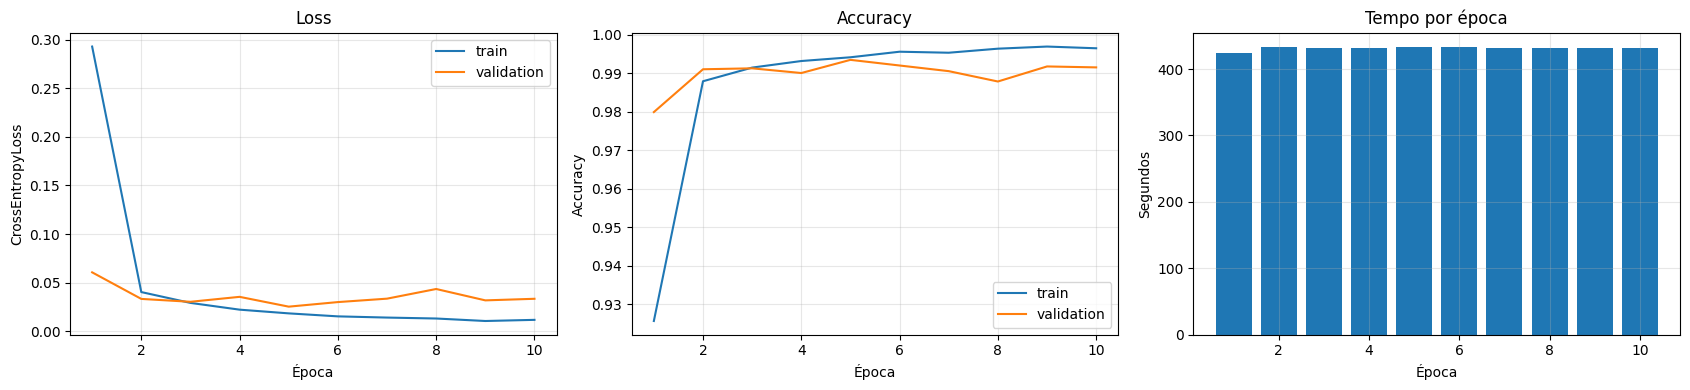

,training
epochs,10
total_time_seconds,4315.008296
average_time_per_epoch_seconds,431.50083
measurement_scope,sum_of_epoch_train_and_validation_passes
epochs_executed,10
best_epoch,5
best_validation_loss,0.025296
stopped_epoch,10
early_stopping,True


,validation_inference
total_time_seconds,29.788759
average_time_per_image_seconds,0.003645
throughput_images_per_second,274.331667
num_images,8172
warmup_batches,1
measurement_scope,end_to_end_dataloader


In [10]:
history_df = pd.DataFrame(history)
display(history_df)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].plot(history_df['epoch'], history_df['train_loss'], label='train')
axes[0].plot(history_df['epoch'], history_df['validation_loss'], label='validation')
axes[0].set(title='Loss', xlabel='Época', ylabel='CrossEntropyLoss')
axes[0].legend()
axes[1].plot(history_df['epoch'], history_df['train_accuracy'], label='train')
axes[1].plot(history_df['epoch'], history_df['validation_accuracy'], label='validation')
axes[1].set(title='Accuracy', xlabel='Época', ylabel='Accuracy')
axes[1].legend()
axes[2].bar(history_df['epoch'], history_df['epoch_time_seconds'])
axes[2].set(title='Tempo por época', xlabel='Época', ylabel='Segundos')
for axis in axes:
    axis.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

with (RESNET50_RESULTS_DIR / 'timing_summary.json').open(encoding='utf-8') as file:
    timing_summary = json.load(file)
display(pd.Series(timing_summary['training'], name='training').to_frame())
display(pd.Series(timing_summary['validation_inference'], name='validation_inference').to_frame())

## Métricas por modelo e por classe

In [11]:
validation_metrics_df = pd.read_csv(RESNET50_RESULTS_DIR / 'validation_metrics.csv')
class_metrics_df = pd.read_csv(RESNET50_RESULTS_DIR / 'validation_metrics_by_class.csv')
display(validation_metrics_df.T.rename(columns={0: 'value'}))
display(class_metrics_df)

,value
accuracy,0.993514
precision_macro,0.990350
recall_macro,0.991895
f1_macro,0.990969
precision_weighted,0.993689
recall_weighted,0.993514
f1_weighted,0.993511
num_samples,8172.000000
num_classes,38.000000


,class_index,class_name,precision,recall,f1_score,support
0,0,Apple___Apple_scab,1.000000,0.989474,0.994709,95
1,1,Apple___Black_rot,1.000000,1.000000,1.000000,95
2,2,Apple___Cedar_apple_rust,1.000000,1.000000,1.000000,43
3,3,Apple___healthy,0.995951,0.995951,0.995951,247
4,4,Blueberry___healthy,0.995614,1.000000,0.997802,227
5,5,Cherry_(including_sour)___Powdery_mildew,0.993711,1.000000,0.996845,158
6,6,Cherry_(including_sour)___healthy,1.000000,0.969231,0.984375,130
7,7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,0.925926,0.974026,0.949367,77
8,8,Corn_(maize)___Common_rust_,1.000000,0.994413,0.997199,179
9,9,Corn_(maize)___Northern_Leaf_Blight,0.979310,0.959459,0.969283,148


## Matriz de confusão da validação

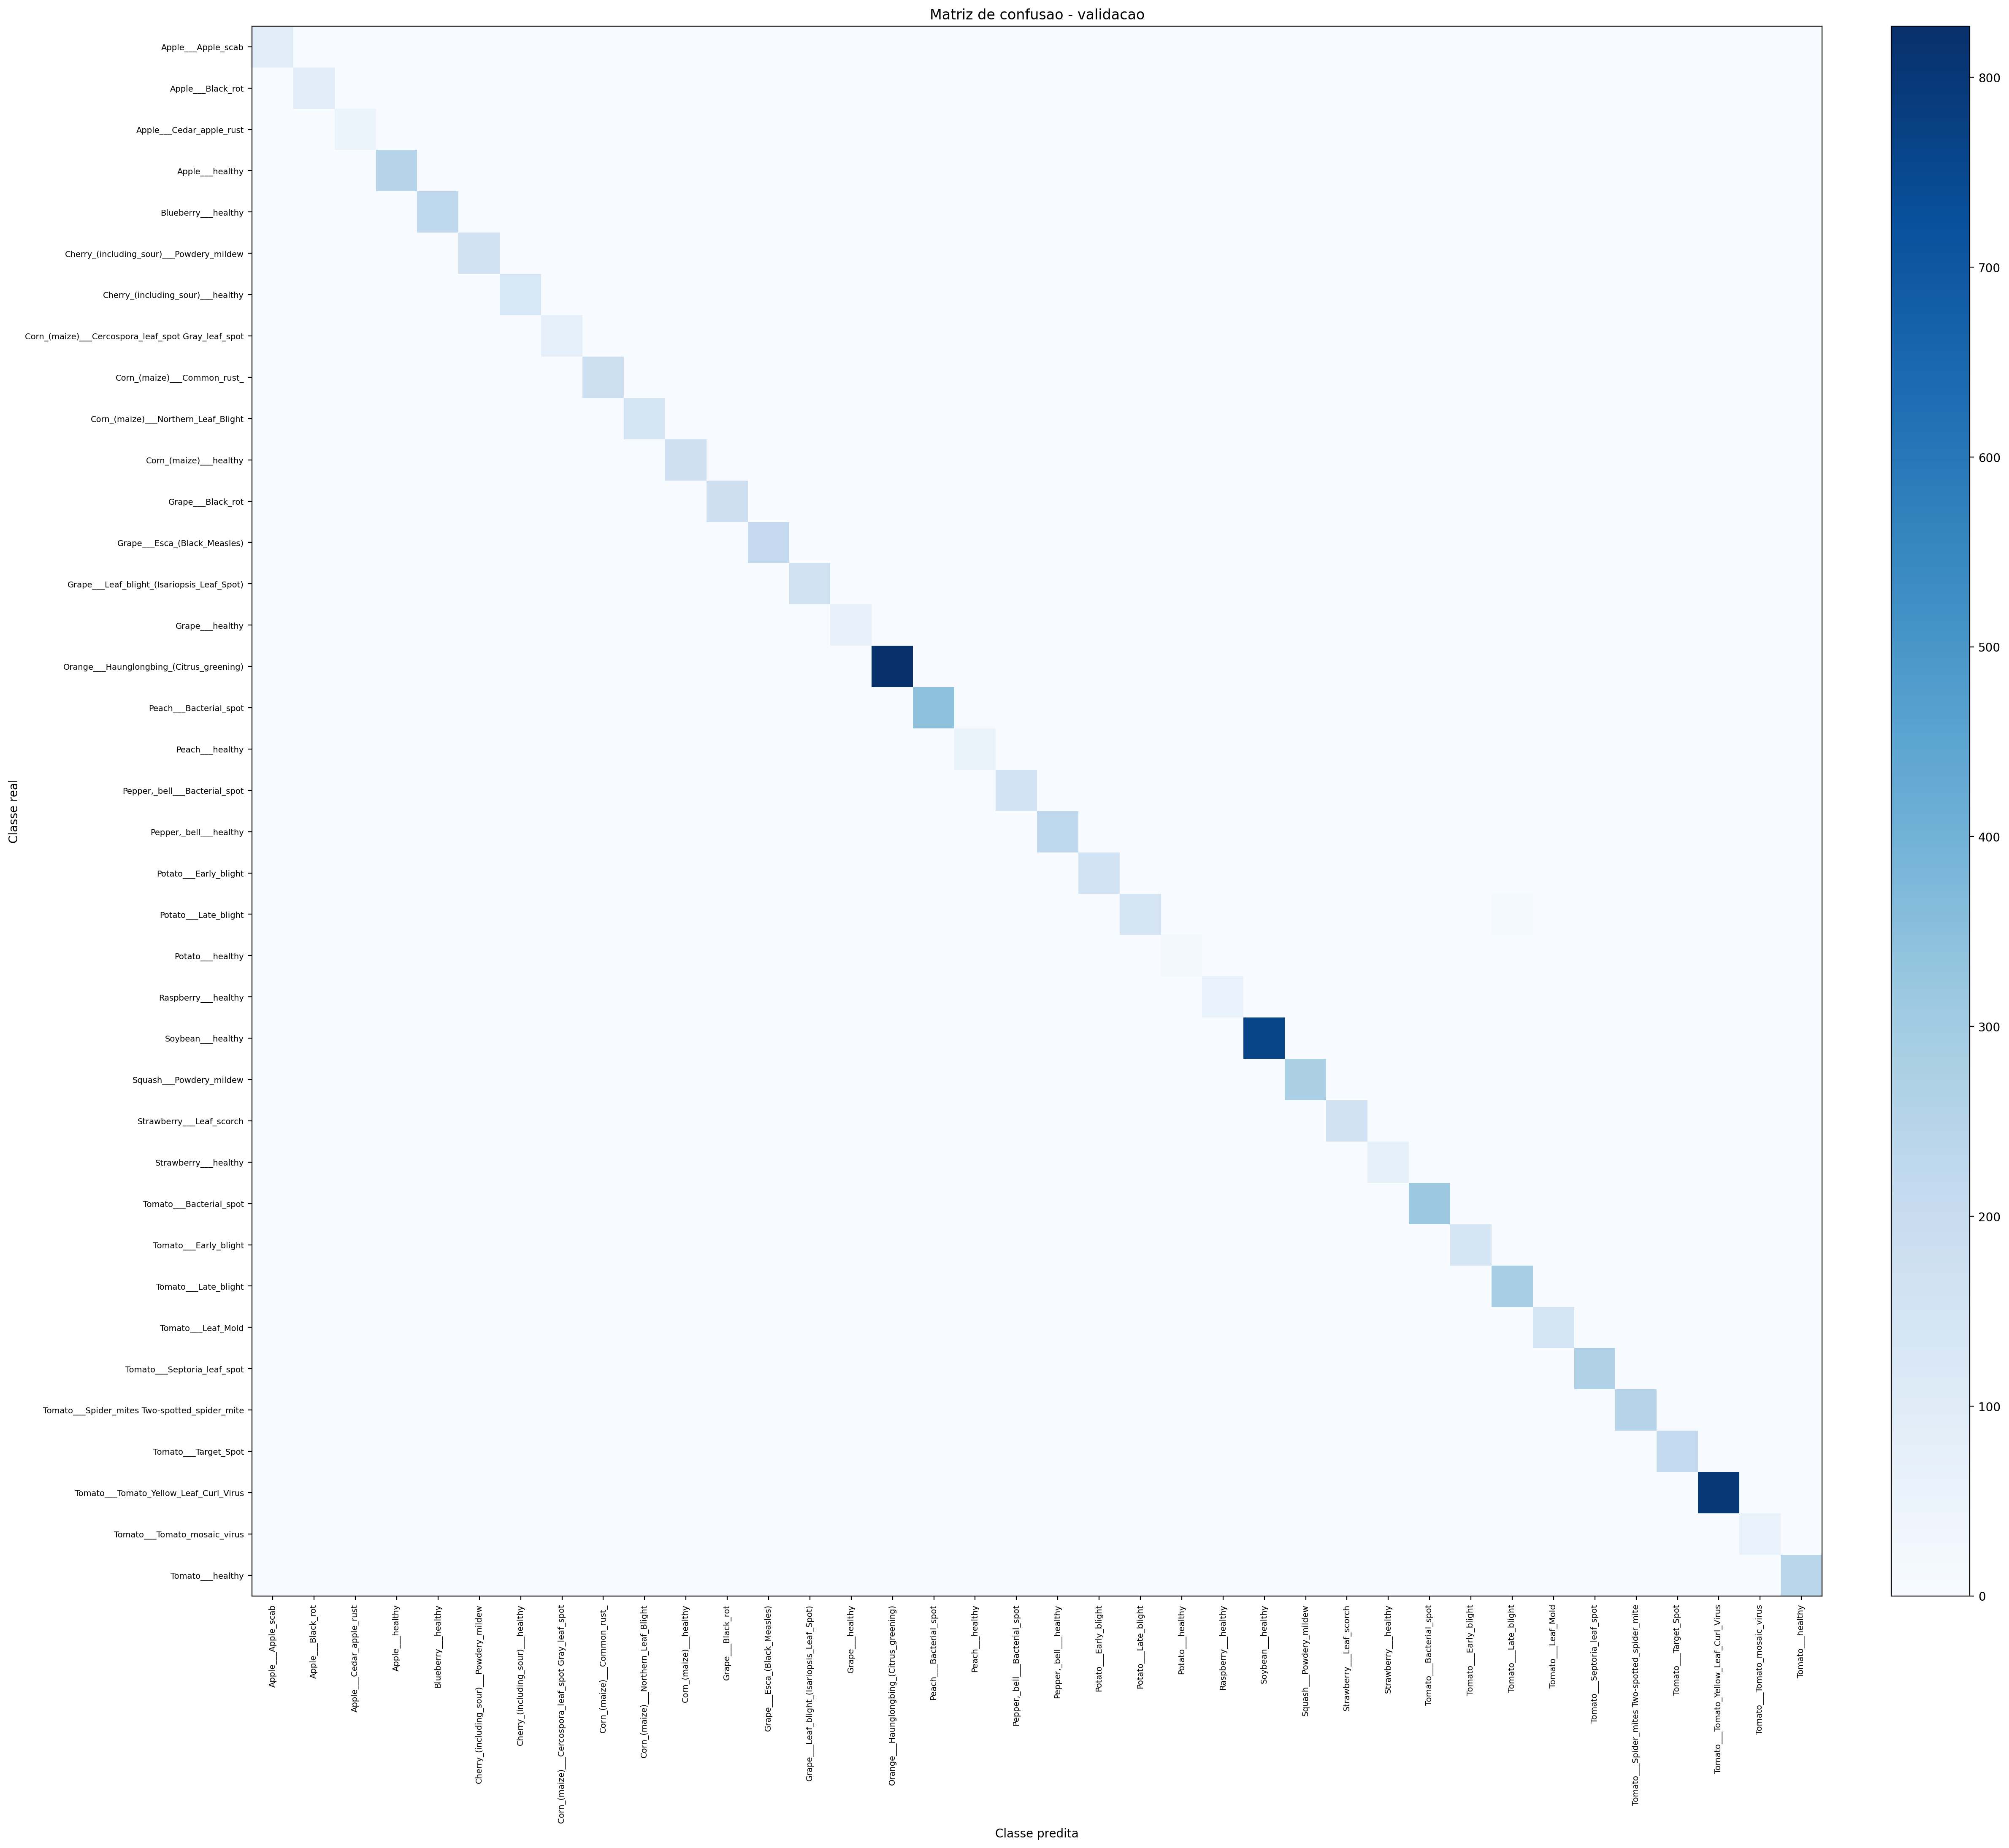

In [12]:
confusion_matrix_path = RESNET50_RESULTS_DIR / 'validation_confusion_matrix.png'
display(Image(filename=str(confusion_matrix_path), width=1100))

## Artefatos gerados

In [13]:
artifacts = sorted(path for path in RESNET50_RESULTS_DIR.iterdir() if path.is_file())
display(pd.DataFrame({
    'arquivo': [path.name for path in artifacts],
    'caminho': [str(path) for path in artifacts],
    'tamanho_bytes': [path.stat().st_size for path in artifacts],
}))

with (RESNET50_RESULTS_DIR / 'experiment_metadata.json').open(encoding='utf-8') as file:
    experiment_metadata = json.load(file)
display(pd.Series(experiment_metadata, name='experiment_metadata').to_frame())
print('Todos os resultados da ResNet50 estão em:', RESNET50_RESULTS_DIR)

,arquivo,caminho,tamanho_bytes
0,architecture_summary.json,/content/drive/MyDrive/plant-disease-classific...,27114
1,experiment_metadata.json,/content/drive/MyDrive/plant-disease-classific...,2037
2,resnet50_best.pth,/content/drive/MyDrive/plant-disease-classific...,283481967
3,resnet50_history.csv,/content/drive/MyDrive/plant-disease-classific...,1070
4,timing_summary.json,/content/drive/MyDrive/plant-disease-classific...,653
5,validation_confusion_matrix.png,/content/drive/MyDrive/plant-disease-classific...,505772
6,validation_metrics.csv,/content/drive/MyDrive/plant-disease-classific...,260
7,validation_metrics_by_class.csv,/content/drive/MyDrive/plant-disease-classific...,2722


,experiment_metadata
execution_timestamp,2026-09-21T01:08:40.173560+00:00
operating_system,Linux
platform,Linux-6.6.122+-x86_64-with-glibc2.39
python_version,"3.13.15 (main, Aug 6 2026, 11:06:22) [GCC 13...."
pytorch_version,2.11.0+cu128
torchvision_version,0.26.0+cu128
cuda_available,True
pytorch_cuda_version,12.8
selected_device,cuda
gpu_name,Tesla T4


Todos os resultados da ResNet50 estão em: /content/drive/MyDrive/plant-disease-classification/results/resnet50
